### Pairs trading with 2 assets

Overall, the exercise suggests that even a very simple cross-sectional stat-arb construction can improve risk adjusted returns with respect to a simple 50/50 buy & hold benchmark, which is notable given that short-horizon relative-value signals are widely researched and heavily contested across the industry. The more important takeaway is that a basic, crowded formulation still appears to retain some value, implying that careful improvements such as better neutralization, transaction cost modeling, execution lags, and alternative “less-contested” feature spaces—could bring more meaningful incremental performance.

In [66]:
import yfinance as yf
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

### Download tickers

In [67]:
visa_mastercard = ['V', 'MA']

data = yf.download(tickers=visa_mastercard, interval='1d')['Close']

data = data.dropna()

print(data.head())
print(data.tail())

[*********************100%***********************]  2 of 2 completed

Ticker             MA          V
Date                            
2008-03-19  19.025467  12.467571
2008-03-20  20.120125  14.199786
2008-03-24  19.765890  13.180312
2008-03-25  20.540094  13.957059
2008-03-26  20.345627  14.113729
Ticker              MA           V
Date                              
2026-01-16  539.489990  328.299988
2026-01-20  531.739990  325.820007
2026-01-21  527.570007  325.279999
2026-01-22  532.859985  326.359985
2026-01-23  524.739990  326.179993


### Obtaining returns

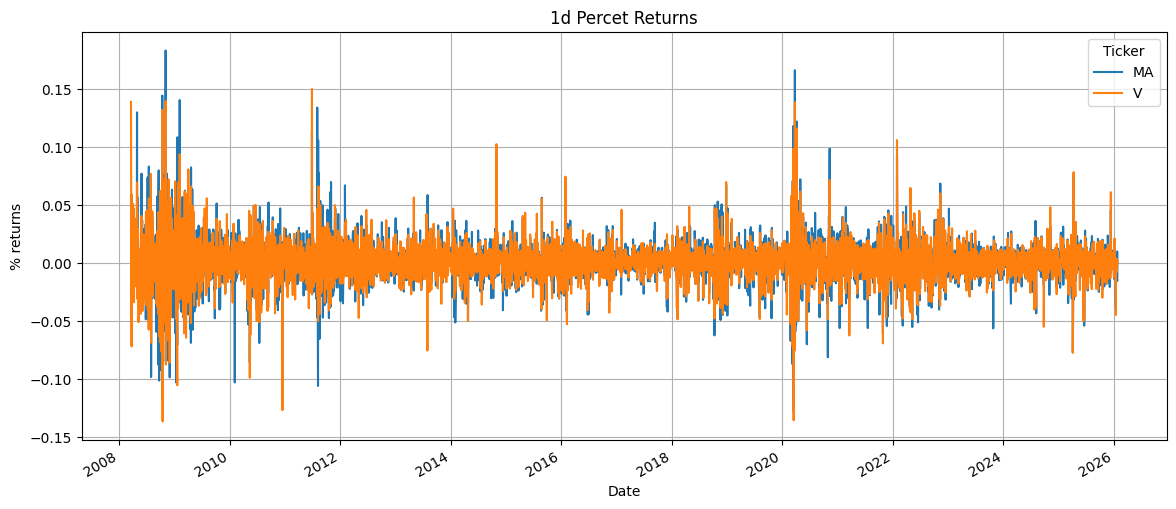

In [68]:
returns = data.pct_change()

returns.plot(grid=True, figsize=(14,6))
plt.title("1d Percet Returns")
plt.ylabel('% returns')
plt.show()

### Extracting signals 

this is done based on how much their individual returns deviate from the average on a 5 day rolling period and that translates into the weights

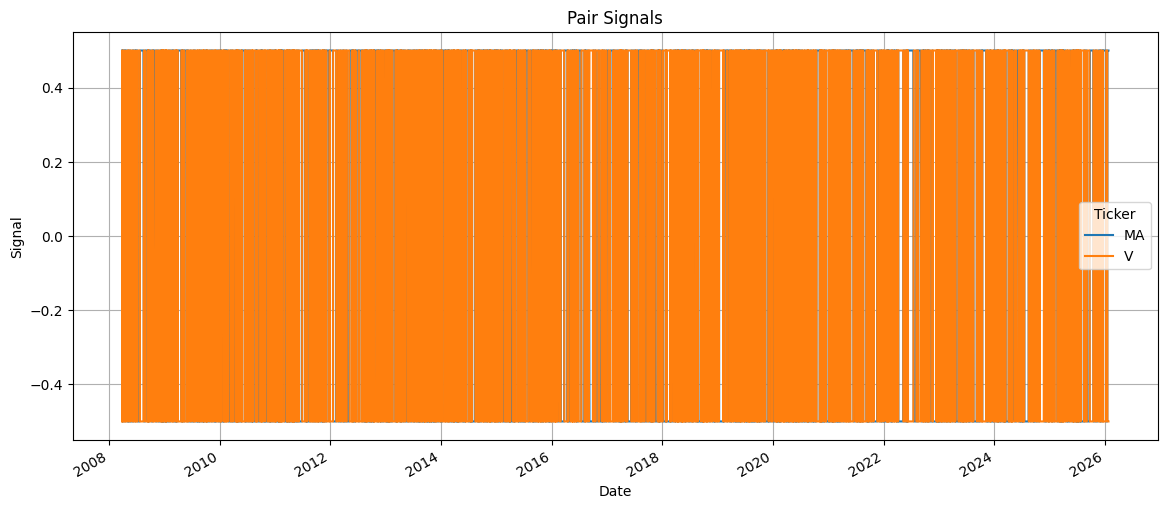

In [69]:
pair_signal = -(returns.rolling(5).sum().subtract(
    returns.rolling(5).sum().mean(axis=1), 
    axis=0
    )
)

pair_signal = (pair_signal.divide(
    pair_signal.abs().sum(axis=1),
    axis = 0
    )
)

pair_signal.plot(grid=True, figsize=(14,6))
plt.title('Pair Signals')
plt.ylabel('Signal')
plt.show()

### Returns without reinvestments

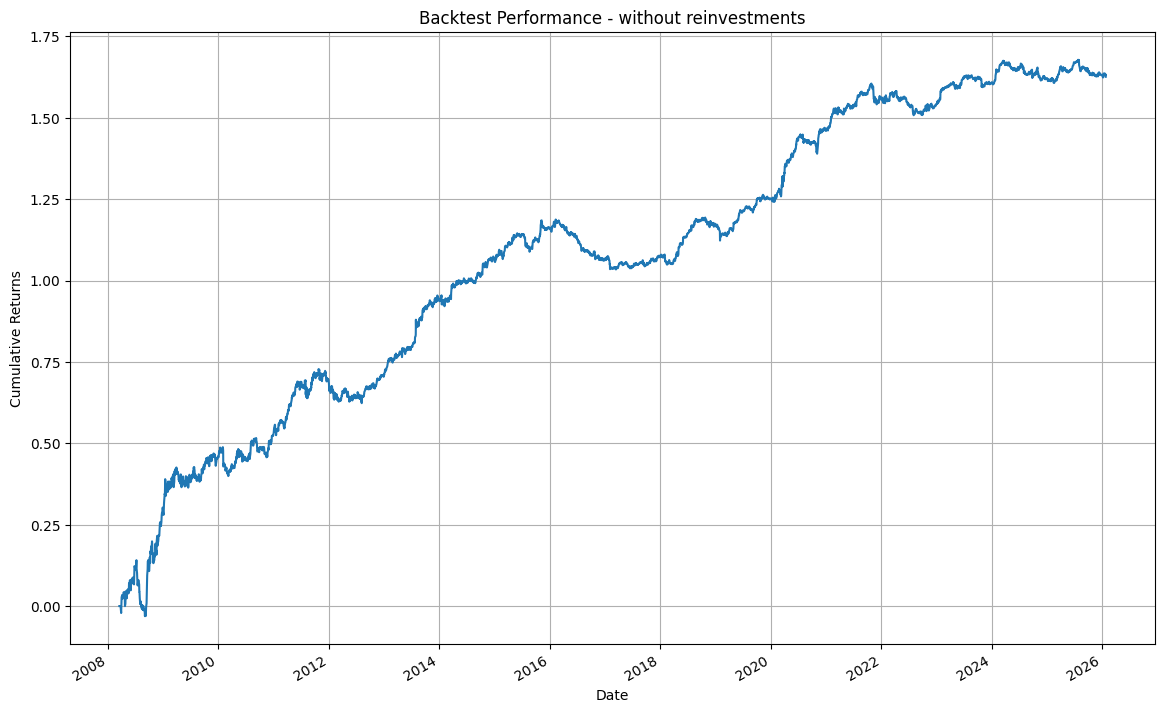

In [70]:
performance = pair_signal.shift(1).multiply(returns).sum(axis=1).cumsum()

performance.plot(grid=True, figsize=(14, 9))
plt.title('Backtest Performance - without reinvestments')
plt.ylabel('Cumulative Returns')
plt.show()

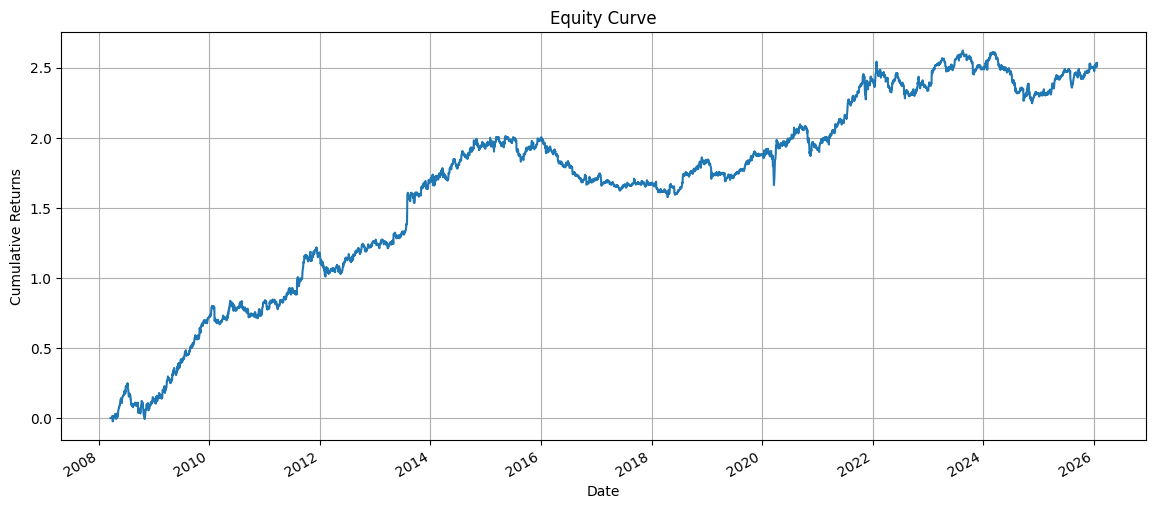

In [71]:
daily_pnl = pair_signal.shift(2).multiply(returns).sum(1)
equity_curve = (1 + daily_pnl).cumprod() - 1

equity_curve.plot(grid=True, figsize=(14, 6))
plt.title('Equity Curve')
plt.ylabel('Cumulative Returns')
plt.show()

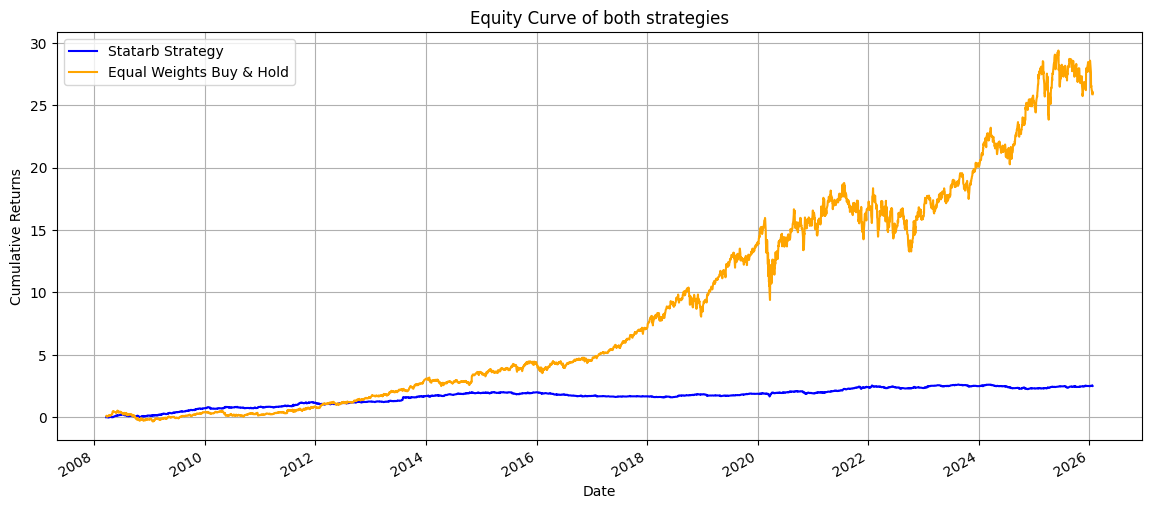

In [72]:
px = (1 + returns).cumprod() 
equal_weights_bh = (0.5 * px.iloc[:,0] + 0.5 * px.iloc[:,1]) - 1

df = pd.concat([equity_curve.rename('Statarb Strategy'), equal_weights_bh.rename('Equal Weights Buy & Hold')], axis=1)

df.plot(grid=True, figsize=(14, 6), color=["blue", "orange"],)
plt.title('Equity Curve of both strategies')
plt.ylabel('Cumulative Returns')
plt.show()

### Performance Stats - Statarb Strategy

In [73]:
total_return = equity_curve.iloc[-1]
annual_vol = daily_pnl.std() * np.sqrt(252)
sharpe = (daily_pnl.mean() / daily_pnl.std()) * np.sqrt(252)

print('Statarb')
print('Total return: ', total_return)
print('Volatility: ', annual_vol)
print('Sharpe Ratio: ', sharpe)

Statarb
Total return:  2.5086633885775265
Volatility:  0.08586192436358736
Sharpe Ratio:  0.863306002006237


### Performance Stats - 50/50 Buy & Hold

In [74]:
total_return_bh = equal_weights_bh.iloc[-1]
bh_daily_ret = equal_weights_bh.pct_change().dropna()
annual_vol_bh = bh_daily_ret.std() * np.sqrt(252)
sharpe_bh = (bh_daily_ret.mean() / bh_daily_ret.std()) * np.sqrt(252)

print('Buy & Hold Benchmark')
print('Total return: ', total_return_bh)
print('Volatility: ', annual_vol_bh)
print('Sharpe Ratio: ', sharpe_bh)

Buy & Hold Benchmark
Total return:  25.871598958765787
Volatility:  6.143700016627267
Sharpe Ratio:  0.023326533988470847
